# `PoissonSampler`

A **Poisson point process** places points randomly such that the expected
number of points in any region $A$ is

$$\Lambda(A) = \iint_A \lambda(x,y)\,dA$$

where $\lambda(x,y)$ is the *intensity surface* (points per unit area).
The total count $N \sim \text{Poisson}(\Lambda)$ is itself random --
that is what makes it a true inhomogeneous Poisson point process.

`PoissonSampler` accepts four ways to specify the intensity surface:

| `intensity` argument | Algorithm |
|---|---|
| **callable** `f(x, y) -> array` | Lewis-Shedler thinning |
| **rasterio.DatasetReader** or **(rows, cols) ndarray** | Pixel-selection or bilinear thinning |
| **1-D array / Series** (when `geometry` contains polygons) | Rasterise per-feature values, then pixel-selection |
| **GeoSeries / GeoDataFrame of Points** or **(N, 2) ndarray** | KDE, then Lewis-Shedler thinning |

Pass `n_expected` to the constructor to control the expected total count;
the sampler normalises the intensity surface internally.
Omitting `n_expected` uses the raw integral of the surface as $E[N]$.

**Dataset:** Chicago community areas (`geoda.chicago_health`)
**Raster:** JRC GHSL 2015 population (250 m), pre-built as `ghsl_chicago_utm.tif`


In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geodatasets
import rasterio
import shapely

from spml.validation import PoissonSampler, PointSampler

%matplotlib inline


/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
chicago = gpd.read_file(geodatasets.get_path('geoda.chicago_health')).to_crs('EPSG:32616')
window  = chicago.union_all()
minx, miny, maxx, maxy = window.bounds
cx, cy = window.centroid.x, window.centroid.y
print(f'Window: {(maxx-minx)/1000:.1f} x {(maxy-miny)/1000:.1f} km  (UTM 16N)')
print(f'Chicago: {len(chicago)} community areas')
chicago[['community', 'VlntCrRt', 'PerCInc14']].head()


Window: 34.3 x 42.1 km  (UTM 16N)
Chicago: 77 community areas


,community,VlntCrRt,PerCInc14
0,DOUGLAS,0.0408,215254
1,OAKLAND,0.0314,54204
2,FULLER PARK,0.0979,32828
3,GRAND BOULEVARD,0.0463,293535
4,KENWOOD,0.0234,261582


## Controlling expected count with `n_expected`

Pass `n_expected` to the constructor and `PoissonSampler` handles the
normalisation internally -- no manual scale computation needed.
The actual N is still random (Poisson), so it will vary around the target.

We set `N_TARGET = 400` for all four modes so the results are comparable.


In [3]:
N_TARGET = 200


## Mode 1 — callable

Any function `f(x, y) -> array` that returns intensity values at an
array of coordinates.  Here we use a distance-decay surface centred on
the city centroid.


In [4]:
def lambda_fn(x, y):
    dist = np.sqrt((x - cx)**2 + (y - cy)**2)
    return 3e-6 * np.exp(-dist / 9_000)

pts_call = PoissonSampler(n_expected=N_TARGET, random_state=42).sample(window, lambda_fn)
print(f'N = {len(pts_call)}  (E[N] = {N_TARGET})')


N = 117  (E[N] = 200)


## Mode 2 — raster

A `rasterio.DatasetReader` (or a 2-D ndarray) is used as the intensity
surface.  With `interpolation='linear'` (default), bilinear interpolation
feeds Lewis-Shedler thinning; `interpolation='nearest'` uses the faster
pixel-selection algorithm.

Here we use the JRC GHSL 2015 population raster clipped to Chicago.


In [5]:
with rasterio.open('ghsl_chicago_utm.tif') as ds:
    pts_raster = PoissonSampler(
        n_expected=N_TARGET, interpolation='linear', random_state=42
    ).sample(window, ds)
print(f'N = {len(pts_raster)}  (E[N] = {N_TARGET})')


N = 180  (E[N] = 200)


## Mode 3 — per-polygon intensity

When `geometry` is a GeoSeries or GeoDataFrame of polygons and `intensity`
is a 1-D numeric array or Series (one value per feature), the sampler
burns the values into a raster aligned to the bounding box and applies
the pixel-selection algorithm.

This is a convenient way to sample proportionally to any areal variable
without having to create a raster yourself.


In [6]:
pts_poly = PoissonSampler(n_expected=N_TARGET, random_state=42).sample(
    chicago.geometry, chicago['VlntCrRt'].fillna(0)
)
print(f'N = {len(pts_poly)}  (E[N] = {N_TARGET})')


N = 212  (E[N] = 200)


## Mode 4 — KDE from an observed point pattern

Pass a GeoSeries or GeoDataFrame of Points (or an (N, 2) ndarray) and
`PoissonSampler` fits a 2-D kernel-density estimate internally and uses
it as the intensity surface.  Control the bandwidth with the `bandwidth`
constructor argument (`None` applies Scott's rule).

Here we generate synthetic crime incident locations from the per-area
violent crime rate and let the sampler learn the spatial pattern.


In [7]:
rng_seed = np.random.default_rng(7)
crime_pts_list = []
for _, row in chicago.iterrows():
    rate = max(row['VlntCrRt'] or 0, 0)
    n = max(1, round(4 * rate / chicago['VlntCrRt'].max()))
    p = PointSampler(n_samples=n,
                     random_state=int(rng_seed.integers(0, 9_999))).sample(row.geometry)
    crime_pts_list.append(p)
crime_pts = pd.concat(crime_pts_list, ignore_index=True)

pts_kde = PoissonSampler(n_expected=N_TARGET, bandwidth=2_500, random_state=42).sample(
    window, crime_pts
)
print(f'N = {len(pts_kde)}  (E[N] = {N_TARGET})')


N = 194  (E[N] = 200)


## Comparison figure

All four modes target the same expected count.  The intensity surface used
by each mode is shown in colour; sampled points are overlaid.


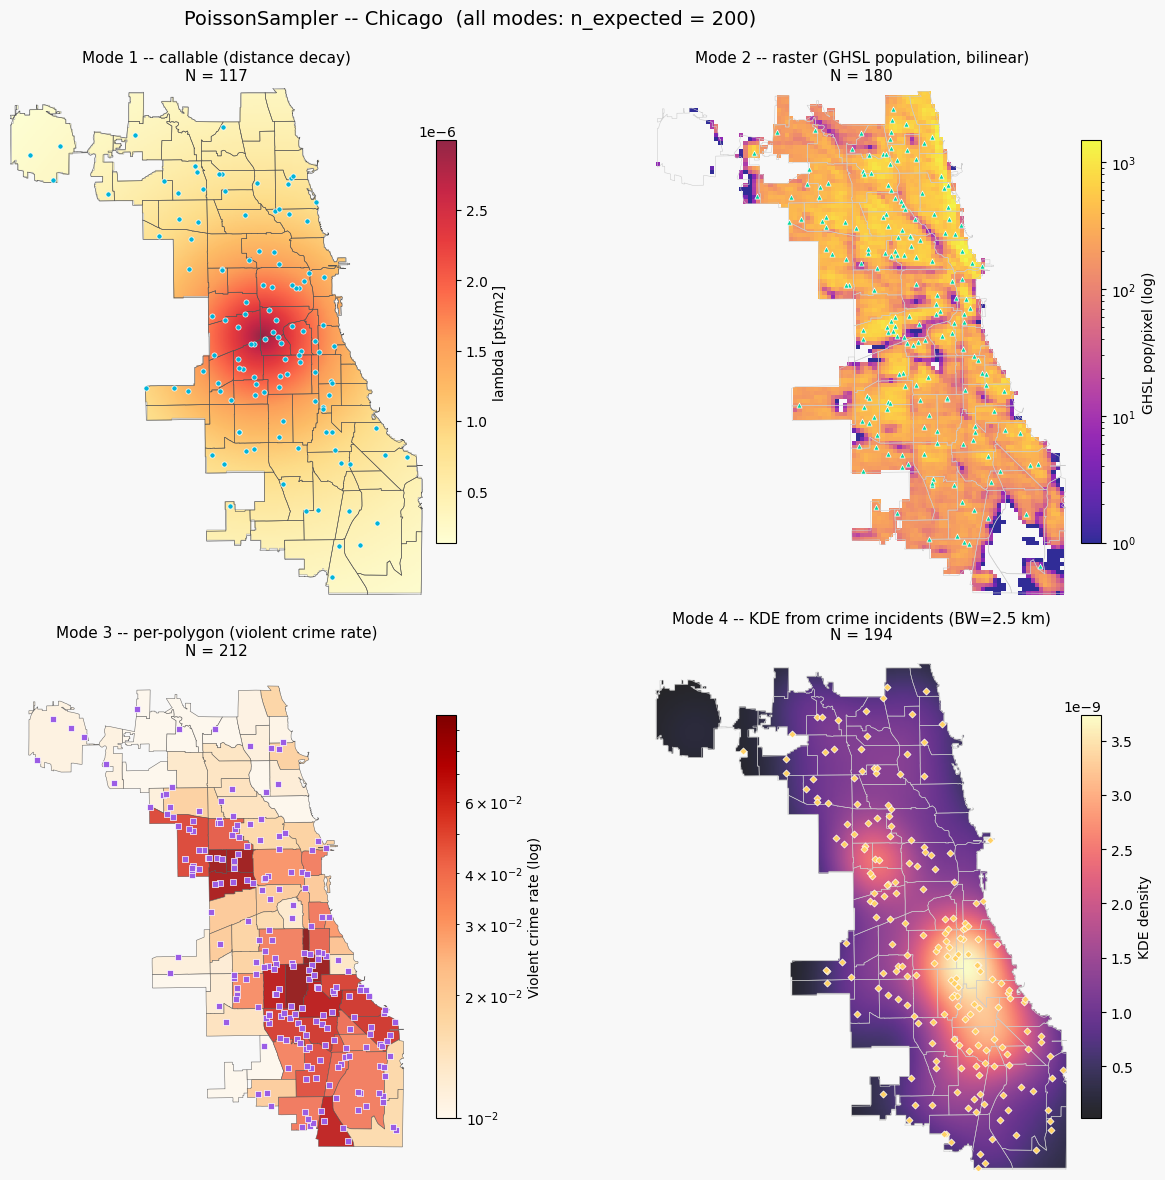

In [8]:
# Build visualisation grids
gx = np.linspace(minx, maxx, 250)
gy = np.linspace(miny, maxy, 250)
GX, GY = np.meshgrid(gx, gy)
grid_pts = shapely.points(GX.ravel(), GY.ravel())
inside   = shapely.contains(window, grid_pts).reshape(GX.shape)

# Mode 1 surface
Z_call = np.where(inside, lambda_fn(GX.ravel(), GY.ravel()).reshape(GX.shape), np.nan)

# Mode 2 surface (GHSL raster)
with rasterio.open('ghsl_chicago_utm.tif') as ds:
    ghsl_arr = np.maximum(ds.read(1).astype(float), 0.0)
    ghsl_tf  = ds.transform
nrows_g, ncols_g = ghsl_arr.shape
rext = [ghsl_tf.c, ghsl_tf.c + ncols_g * ghsl_tf.a,
        ghsl_tf.f + nrows_g * ghsl_tf.e, ghsl_tf.f]
pop_show = np.where(ghsl_arr > 0, ghsl_arr, np.nan)

# Mode 4 surface (KDE)
from sklearn.neighbors import KernelDensity
kde_vis = KernelDensity(bandwidth=2_500, kernel='gaussian')
kde_vis.fit(np.column_stack([crime_pts.geometry.x, crime_pts.geometry.y]))
Z_kde = np.where(
    inside,
    np.exp(kde_vis.score_samples(
        np.column_stack([GX.ravel(), GY.ravel()])
    )).reshape(GX.shape),
    np.nan,
)

PT = dict(s=14, zorder=6, edgecolors='white', linewidths=0.5)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.patch.set_facecolor('#f8f8f8')

# Mode 1 -- callable
ax = axes[0, 0]
im1 = ax.imshow(Z_call, origin='lower', extent=[minx, maxx, miny, maxy],
                cmap='YlOrRd', alpha=0.85, aspect='equal')
chicago.boundary.plot(ax=ax, color='#555', linewidth=0.4)
ax.scatter(pts_call.geometry.x, pts_call.geometry.y,
           color='#00b4d8', marker='o', **PT)
plt.colorbar(im1, ax=ax, fraction=0.03, pad=0.02, label='lambda [pts/m2]')
ax.set_title(f'Mode 1 -- callable (distance decay)\nN = {len(pts_call)}', fontsize=11)
ax.axis('off')

# Mode 2 -- raster
ax = axes[0, 1]
norm2 = mcolors.LogNorm(vmin=max(ghsl_arr[ghsl_arr > 0].min(), 1), vmax=ghsl_arr.max())
im2 = ax.imshow(pop_show, origin='upper', extent=[rext[0], rext[1], rext[2], rext[3]],
                cmap='plasma', norm=norm2, alpha=0.85, aspect='equal')
chicago.boundary.plot(ax=ax, color='#ccc', linewidth=0.4)
ax.scatter(pts_raster.geometry.x, pts_raster.geometry.y,
           color='#06d6a0', marker='^', **PT)
plt.colorbar(im2, ax=ax, fraction=0.03, pad=0.02, label='GHSL pop/pixel (log)')
ax.set_title(f'Mode 2 -- raster (GHSL population, bilinear)\nN = {len(pts_raster)}', fontsize=11)
ax.axis('off')

# Mode 3 -- polygon intensity
ax = axes[1, 0]
vmin3 = max(chicago['VlntCrRt'].fillna(0).replace(0, np.nan).min(), 0.01)
vmax3 = chicago['VlntCrRt'].max()
norm3 = mcolors.LogNorm(vmin=vmin3, vmax=vmax3)
chicago.plot(column='VlntCrRt', cmap='OrRd', legend=False, norm=norm3,
             edgecolor='#555', linewidth=0.4, ax=ax, alpha=0.85)
ax.scatter(pts_poly.geometry.x, pts_poly.geometry.y,
           color='#9b5de5', marker='s', **PT)
sm = plt.cm.ScalarMappable(cmap='OrRd', norm=norm3)
plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, label='Violent crime rate (log)')
ax.set_title(f'Mode 3 -- per-polygon (violent crime rate)\nN = {len(pts_poly)}', fontsize=11)
ax.axis('off')

# Mode 4 -- KDE
ax = axes[1, 1]
im4 = ax.imshow(Z_kde, origin='lower', extent=[minx, maxx, miny, maxy],
                cmap='magma', alpha=0.85, aspect='equal')
chicago.boundary.plot(ax=ax, color='#ccc', linewidth=0.4)
ax.scatter(pts_kde.geometry.x, pts_kde.geometry.y,
           color='#ffd166', marker='D', s=13, zorder=6,
           edgecolors='white', linewidths=0.5)
plt.colorbar(im4, ax=ax, fraction=0.03, pad=0.02, label='KDE density')
ax.set_title(f'Mode 4 -- KDE from crime incidents (BW=2.5 km)\nN = {len(pts_kde)}', fontsize=11)
ax.axis('off')

fig.suptitle(
    f'PoissonSampler -- Chicago  (all modes: n_expected = {N_TARGET})',
    fontsize=14,
)
fig.tight_layout()
plt.show()
